# 09 - Integridad de Secuencia y Timestamps

## Objetivo cientifico
Evaluar si el orden temporal de eventos de trades es coherente para analitica y backtesting.

Lectura clave:
- `out_of_order` alto: eventos desordenados en tiempo (riesgo para simulacion/event studies).
- `duplicate_timestamp` alto: muchos eventos comparten exactamente el mismo timestamp.

Que significa `duplicate_timestamp` alto:
- No implica automaticamente corrupcion.
- Suele indicar resolucion temporal limitada del feed (coarsening), agregacion por proveedor o burst de prints en el mismo instante de reloj.
- Impacta logica sensible al orden intra-milisegundo y modelos de latencia/fill.


## Paso 1 - Setup y muestra controlada


In [1]:
NOTEBOOK_ID = "09_sequence_timestamp_integrity"

import json
import os
import sys
import uuid
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import polars as pl

try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("matplotlib not available:", e)


def detect_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for cand in candidates:
        if (cand / "data" / "manifests").exists() and (cand / "notebooks" / "01_data_integrity").exists():
            return cand
    return cwd


PROJECT_ROOT = detect_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

DATA_ROOT = Path(os.getenv("DATA_CACHE_DIR", r"C:\TSIS_Data\data")).resolve()
SYMBOLS = ["AABA"]
MAX_FILES = 300
ROWS_PER_FILE = 2000

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
OUT_DIR = PROJECT_ROOT / "runs" / "data_quality" / NOTEBOOK_ID / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT).decode().strip()
except Exception:
    git_commit = "<unknown>"

print("Run ID:", RUN_ID)
print("Out dir:", OUT_DIR)
print("Data root:", DATA_ROOT)
print("Symbols:", SYMBOLS)


def list_trade_files(data_root: Path, symbols: list[str], max_files: int) -> list[Path]:
    files = []
    roots = ["trades_ticks_2004_2018", "trades_ticks_2019_2025"]
    for r in roots:
        for s in symbols:
            base = data_root / r / s
            if not base.exists():
                continue
            for fp in base.rglob("*.parquet"):
                files.append(fp)
                if len(files) >= max_files:
                    return files
    return files


def sample_concat(files: list[Path], rows_per_file: int) -> pl.DataFrame:
    parts = []
    for fp in files:
        try:
            df = pl.read_parquet(fp).head(rows_per_file)
            parts.append(df)
        except Exception:
            continue
    if not parts:
        return pl.DataFrame()
    return pl.concat(parts, how="diagonal_relaxed")



Run ID: 20260213_124407_d854fc91
Out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\09_sequence_timestamp_integrity\20260213_124407_d854fc91
Data root: C:\TSIS_Data\data
Symbols: ['AABA']


## Paso 2A - Disponibilidad de columnas (schema gate)
Si faltan columnas avanzadas, el notebook lo reporta como `not_available` de forma explicita.


In [2]:
trade_files = list_trade_files(DATA_ROOT, SYMBOLS, MAX_FILES)
trades = sample_concat(trade_files, ROWS_PER_FILE)

seq_col = next((c for c in ["sequence_number", "sequence", "seq"] if c in trades.columns), None)
pt_col = next((c for c in ["participant_timestamp", "participant_ts", "exchange_timestamp"] if c in trades.columns), None)
sip_col = next((c for c in ["sip_timestamp", "sip_ts"] if c in trades.columns), None)
ts_col = next((c for c in ["timestamp", "t", "ts"] if c in trades.columns), None)
ticker_col = next((c for c in ["symbol", "ticker"] if c in trades.columns), None)

print("rows:", trades.height)
print("columns:", sorted(trades.columns))
print("ts:", ts_col, "seq:", seq_col, "participant_ts:", pt_col, "sip_ts:", sip_col, "ticker:", ticker_col)

schema_gate = pl.DataFrame([
    {
        "rows_sampled": int(trades.height),
        "trade_files_sampled": int(len(trade_files)),
        "timestamp_col": ts_col,
        "sequence_col": seq_col,
        "participant_ts_col": pt_col,
        "sip_ts_col": sip_col,
        "sequence_check_status": "available" if seq_col is not None else "not_available",
        "clock_drift_status": "available" if (pt_col is not None and sip_col is not None) else "not_available",
    }
])

schema_gate



rows: 295829
columns: ['conditions', 'date', 'exchange', 'price', 'size', 'ticker', 'timestamp']
ts: timestamp seq: None participant_ts: None sip_ts: None ticker: ticker


rows_sampled,trade_files_sampled,timestamp_col,sequence_col,participant_ts_col,sip_ts_col,sequence_check_status,clock_drift_status
i64,i64,str,null,null,null,str,str
295829,300,"""timestamp""",null,null,null,"""not_available""","""not_available"""


## Paso 2B - Metricas globales y granularidad por archivo


In [3]:
def _path_meta(fp: Path) -> dict:
    rel = fp.relative_to(DATA_ROOT)
    parts = rel.parts
    dataset_root = parts[0] if len(parts) > 0 else "<unknown>"
    ticker = parts[1] if len(parts) > 1 else "<unknown>"
    day = None
    for part in parts:
        if part.startswith("day="):
            day = part.split("=", 1)[1]
            break
    return {
        "dataset_root": dataset_root,
        "ticker": ticker,
        "day": day,
        "session": fp.stem,
        "file_path": str(fp),
    }


def _file_timestamp_integrity(fp: Path, ts_col_name: str, rows_per_file: int) -> dict | None:
    try:
        sample_cols = pl.read_parquet(fp, n_rows=1).columns
        if ts_col_name not in sample_cols:
            return None

        d = pl.read_parquet(fp, columns=[ts_col_name]).head(rows_per_file)
        if d.height == 0:
            return None

        d = d.with_row_index("row_idx").with_columns(pl.col(ts_col_name).cast(pl.Int64, strict=False).alias("ts_i64"))
        d_valid = d.filter(pl.col("ts_i64").is_not_null())

        if d_valid.height == 0:
            return {
                "n_rows": int(d.height),
                "n_valid_ts": 0,
                "n_invalid_ts": int(d.height),
                "n_out_of_order": 0,
                "n_duplicate_ts_rows": 0,
                "out_of_order_share": 0.0,
                "duplicate_timestamp_share": 0.0,
            }

        d_valid = d_valid.with_columns(pl.col("ts_i64").diff().alias("dts"))

        n_valid = int(d_valid.height)
        n_invalid = int(d.height - n_valid)
        n_ooo = int(d_valid.filter(pl.col("dts") < 0).height)

        dup_info = d_valid.group_by("ts_i64").len().filter(pl.col("len") > 1).with_columns((pl.col("len") - 1).alias("dup_extra"))
        n_dup_rows = int(dup_info.select(pl.col("dup_extra").sum()).item()) if dup_info.height > 0 else 0

        return {
            "n_rows": int(d.height),
            "n_valid_ts": n_valid,
            "n_invalid_ts": n_invalid,
            "n_out_of_order": n_ooo,
            "n_duplicate_ts_rows": n_dup_rows,
            "out_of_order_share": float(n_ooo / n_valid) if n_valid else 0.0,
            "duplicate_timestamp_share": float(n_dup_rows / n_valid) if n_valid else 0.0,
        }
    except Exception:
        return None


file_rows = []
if ts_col is not None:
    for fp in trade_files:
        m = _file_timestamp_integrity(fp, ts_col, ROWS_PER_FILE)
        if m is None:
            continue
        file_rows.append({**_path_meta(fp), **m})

gran_file = pl.DataFrame(file_rows) if file_rows else pl.DataFrame()

if gran_file.height > 0:
    total_valid_ts = int(gran_file.select(pl.col("n_valid_ts").sum()).item())
    total_invalid_ts = int(gran_file.select(pl.col("n_invalid_ts").sum()).item())
    total_ooo = int(gran_file.select(pl.col("n_out_of_order").sum()).item())
    total_dup = int(gran_file.select(pl.col("n_duplicate_ts_rows").sum()).item())
else:
    total_valid_ts = total_invalid_ts = total_ooo = total_dup = 0

global_metrics = pl.DataFrame([
    {
        "rows_sampled": int(trades.height),
        "trade_files_sampled": int(len(trade_files)),
        "total_valid_ts": total_valid_ts,
        "total_invalid_ts": total_invalid_ts,
        "total_out_of_order": total_ooo,
        "total_duplicate_ts_rows": total_dup,
        "out_of_order_share": float(total_ooo / total_valid_ts) if total_valid_ts else None,
        "duplicate_timestamp_share": float(total_dup / total_valid_ts) if total_valid_ts else None,
    }
])

print("Global metrics:")
print(global_metrics)

global_metrics



Global metrics:
shape: (1, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ rows_sampl ┆ trade_file ┆ total_vali ┆ total_inv ┆ total_out ┆ total_dup ┆ out_of_or ┆ duplicate │
│ ed         ┆ s_sampled  ┆ d_ts       ┆ alid_ts   ┆ _of_order ┆ licate_ts ┆ der_share ┆ _timestam │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ _rows     ┆ ---       ┆ p_share   │
│ i64        ┆ i64        ┆ i64        ┆ i64       ┆ i64       ┆ ---       ┆ f64       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ i64       ┆           ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 295829     ┆ 300        ┆ 295829     ┆ 0         ┆ 0         ┆ 179225    ┆ 0.0       ┆ 0.60584   │
└────────────┴────────────┴────────────┴───────────┴───────────┴───────────┴───────────┴───────────┘


rows_sampled,trade_files_sampled,total_valid_ts,total_invalid_ts,total_out_of_order,total_duplicate_ts_rows,out_of_order_share,duplicate_timestamp_share
i64,i64,i64,i64,i64,i64,f64,f64
295829,300,295829,0,0,179225,0.0,0.60584


## Paso 2C - Drill-down por archivo, dia y sesion


In [4]:
if gran_file.height > 0:
    gran_day_session = (
        gran_file.group_by(["dataset_root", "ticker", "day", "session"])
        .agg([
            pl.col("n_rows").sum().alias("n_rows"),
            pl.col("n_valid_ts").sum().alias("n_valid_ts"),
            pl.col("n_invalid_ts").sum().alias("n_invalid_ts"),
            pl.col("n_out_of_order").sum().alias("n_out_of_order"),
            pl.col("n_duplicate_ts_rows").sum().alias("n_duplicate_ts_rows"),
        ])
        .with_columns([
            pl.when(pl.col("n_valid_ts") > 0).then(pl.col("n_out_of_order") / pl.col("n_valid_ts")).otherwise(0.0).alias("out_of_order_share"),
            pl.when(pl.col("n_valid_ts") > 0).then(pl.col("n_duplicate_ts_rows") / pl.col("n_valid_ts")).otherwise(0.0).alias("duplicate_timestamp_share"),
        ])
        .sort(["day", "session"])
    )
else:
    gran_day_session = pl.DataFrame()

print("Top files by out_of_order_share:")
if gran_file.height > 0:
    print(gran_file.select(["day", "session", "n_valid_ts", "n_out_of_order", "out_of_order_share"]).sort("out_of_order_share", descending=True).head(10))
else:
    print("no rows")

print("\nTop files by duplicate_timestamp_share:")
if gran_file.height > 0:
    print(gran_file.select(["day", "session", "n_valid_ts", "n_duplicate_ts_rows", "duplicate_timestamp_share"]).sort("duplicate_timestamp_share", descending=True).head(10))
else:
    print("no rows")

session_rollup = pl.DataFrame()
if gran_day_session.height > 0:
    session_rollup = (
        gran_day_session.group_by("session").agg([
            pl.col("n_valid_ts").sum().alias("n_valid_ts"),
            pl.col("n_out_of_order").sum().alias("n_out_of_order"),
            pl.col("n_duplicate_ts_rows").sum().alias("n_duplicate_ts_rows"),
        ]).with_columns([
            pl.when(pl.col("n_valid_ts") > 0).then(pl.col("n_out_of_order") / pl.col("n_valid_ts")).otherwise(0.0).alias("out_of_order_share"),
            pl.when(pl.col("n_valid_ts") > 0).then(pl.col("n_duplicate_ts_rows") / pl.col("n_valid_ts")).otherwise(0.0).alias("duplicate_timestamp_share"),
        ])
    )

print("\nSession rollup:")
print(session_rollup)

session_rollup



Top files by out_of_order_share:
shape: (10, 5)
┌────────────┬───────────┬────────────┬────────────────┬────────────────────┐
│ day        ┆ session   ┆ n_valid_ts ┆ n_out_of_order ┆ out_of_order_share │
│ ---        ┆ ---       ┆ ---        ┆ ---            ┆ ---                │
│ str        ┆ str       ┆ i64        ┆ i64            ┆ f64                │
╞════════════╪═══════════╪════════════╪════════════════╪════════════════════╡
│ 2017-06-19 ┆ market    ┆ 2000       ┆ 0              ┆ 0.0                │
│ 2017-06-19 ┆ premarket ┆ 999        ┆ 0              ┆ 0.0                │
│ 2017-06-20 ┆ market    ┆ 2000       ┆ 0              ┆ 0.0                │
│ 2017-06-20 ┆ premarket ┆ 89         ┆ 0              ┆ 0.0                │
│ 2017-06-21 ┆ market    ┆ 2000       ┆ 0              ┆ 0.0                │
│ 2017-06-21 ┆ premarket ┆ 27         ┆ 0              ┆ 0.0                │
│ 2017-06-22 ┆ market    ┆ 2000       ┆ 0              ┆ 0.0                │
│ 2017-06-22 ┆ p

session,n_valid_ts,n_out_of_order,n_duplicate_ts_rows,out_of_order_share,duplicate_timestamp_share
str,i64,i64,i64,f64,f64
"""premarket""",11777,0,6406,0.0,0.543942
"""market""",284052,0,172819,0.0,0.608406


## Paso 3A - Visual: Out-of-order por sesion


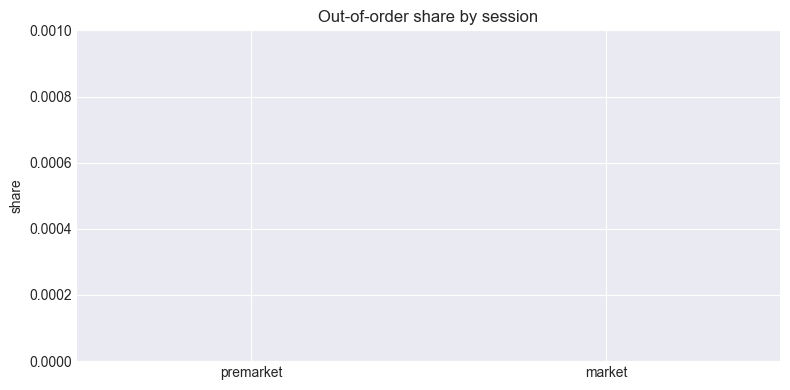

No out-of-order events in sampled data; bars are at zero.


In [5]:
if plt is not None and session_rollup.height > 0:
    sp = pd.DataFrame(session_rollup.to_dicts())
    if not sp.empty:
        plt.style.use("seaborn-v0_8-darkgrid")
        plt.figure(figsize=(8, 4))
        plt.bar(sp["session"], sp["out_of_order_share"])
        plt.title("Out-of-order share by session")
        plt.ylabel("share")
        plt.ylim(0, max(0.001, float(sp["out_of_order_share"].max()) * 1.2))
        plt.tight_layout()
        plt.show()

        if float(sp["out_of_order_share"].sum()) == 0.0:
            print("No out-of-order events in sampled data; bars are at zero.")



## Paso 3B - Visual: Duplicate timestamp por sesion


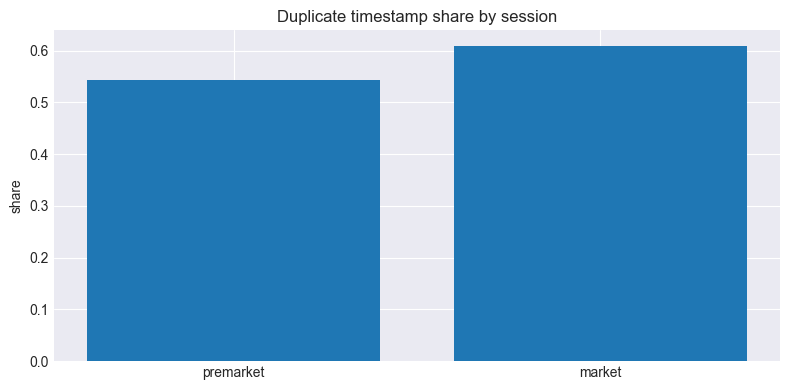

In [6]:
if plt is not None and session_rollup.height > 0:
    sp = pd.DataFrame(session_rollup.to_dicts())
    if not sp.empty:
        plt.style.use("seaborn-v0_8-darkgrid")
        plt.figure(figsize=(8, 4))
        plt.bar(sp["session"], sp["duplicate_timestamp_share"])
        plt.title("Duplicate timestamp share by session")
        plt.ylabel("share")
        plt.tight_layout()
        plt.show()



## Paso 4 - Calibracion automatica de umbrales y gate PASS/WARN/FAIL
Metodologia:
- Se leen runs historicos del propio notebook (`runs/data_quality/09_sequence_timestamp_integrity`).
- Se estiman umbrales dinamicos por percentiles historicos (si hay suficiente historia).
- Si no hay historia suficiente, se usan umbrales de respaldo institucional.

Politica:
- `timestamp` ausente -> `FAIL`.
- `sequence` o `dual-clock` ausente -> `WARN` (cobertura limitada).
- `out_of_order_share` y `duplicate_timestamp_share` se eval?an contra umbrales calibrados.
- `overall_status`: FAIL si hay cualquier FAIL; si no, WARN si hay algun WARN; si no, PASS.



In [7]:
# ---- Auto-calibration from historical runs ----
runs_root = PROJECT_ROOT / "runs" / "data_quality" / NOTEBOOK_ID


def _quantile(vals: list[float], q: float) -> float:
    if not vals:
        return float("nan")
    x = sorted(float(v) for v in vals)
    if len(x) == 1:
        return x[0]
    pos = (len(x) - 1) * q
    lo = int(pos)
    hi = min(lo + 1, len(x) - 1)
    frac = pos - lo
    return x[lo] * (1.0 - frac) + x[hi] * frac


def _calibrate(vals: list[float], default_pass: float, default_warn: float) -> dict:
    vals = [float(v) for v in vals if v is not None]
    n = len(vals)

    if n >= 20:
        p_pass = _quantile(vals, 0.95)
        p_warn = _quantile(vals, 0.99)
        mode = "hist_p95_p99"
    elif n >= 5:
        p_pass = _quantile(vals, 0.90)
        p_warn = _quantile(vals, 0.98)
        mode = "hist_p90_p98"
    elif n > 0:
        p_pass = max(vals)
        p_warn = max(vals) * 1.25
        mode = "hist_max_buffer"
    else:
        p_pass = default_pass
        p_warn = default_warn
        mode = "default_fallback"

    p_pass = max(0.0, min(1.0, float(p_pass)))
    p_warn = max(p_pass + 1e-9, min(1.0, float(p_warn)))

    return {
        "n_history": n,
        "mode": mode,
        "pass_max": p_pass,
        "warn_max": p_warn,
    }


def _status(value, pass_max: float, warn_max: float):
    if value is None:
        return "WARN", "metric_not_available"
    v = float(value)
    if v <= pass_max:
        return "PASS", "within_pass_threshold"
    if v <= warn_max:
        return "WARN", "within_warn_threshold"
    return "FAIL", "exceeds_warn_threshold"


hist_out = []
hist_dup = []
hist_dup_by_session = {}

if runs_root.exists():
    for d in sorted([x for x in runs_root.iterdir() if x.is_dir()], key=lambda x: x.stat().st_mtime):
        if d.name == RUN_ID:
            continue

        m_path = d / "sequence_timestamp_metrics.parquet"
        j_path = d / "sequence_timestamp_decision.json"

        if m_path.exists():
            try:
                m = pl.read_parquet(m_path)
                if m.height > 0:
                    row = m.to_dicts()[0]
                    if row.get("out_of_order_share") is not None:
                        hist_out.append(float(row.get("out_of_order_share")))
                    if row.get("duplicate_timestamp_share") is not None:
                        hist_dup.append(float(row.get("duplicate_timestamp_share")))
            except Exception:
                pass

        if j_path.exists():
            try:
                j = json.loads(j_path.read_text(encoding="utf-8"))
                for rr in j.get("session_rollup", []):
                    sess = rr.get("session")
                    if not sess:
                        continue
                    v = rr.get("duplicate_timestamp_share")
                    if v is None:
                        continue
                    hist_dup_by_session.setdefault(sess, []).append(float(v))
            except Exception:
                pass

# Fallback defaults (institutional seed policy)
out_thr = _calibrate(hist_out, default_pass=1e-5, default_warn=1e-4)
dup_thr = _calibrate(hist_dup, default_pass=0.10, default_warn=0.35)

session_thr = {}
for sess, vals in hist_dup_by_session.items():
    session_thr[sess] = _calibrate(vals, default_pass=dup_thr["pass_max"], default_warn=dup_thr["warn_max"])

metrics_eval = schema_gate.hstack(global_metrics.select([
    "total_valid_ts",
    "total_invalid_ts",
    "total_out_of_order",
    "total_duplicate_ts_rows",
    "out_of_order_share",
    "duplicate_timestamp_share",
]))

mrow = metrics_eval.to_dicts()[0] if metrics_eval.height > 0 else {}

schema_status = "FAIL" if mrow.get("timestamp_col") is None else "PASS"
schema_reason = "timestamp_missing" if mrow.get("timestamp_col") is None else "timestamp_available"

seq_status = "WARN" if mrow.get("sequence_check_status") != "available" else "PASS"
seq_reason = "sequence_column_not_available" if seq_status == "WARN" else "sequence_column_available"

clock_status = "WARN" if mrow.get("clock_drift_status") != "available" else "PASS"
clock_reason = "dual_clock_not_available" if clock_status == "WARN" else "dual_clock_available"

out_status, out_reason = _status(mrow.get("out_of_order_share"), out_thr["pass_max"], out_thr["warn_max"])
dup_status, dup_reason = _status(mrow.get("duplicate_timestamp_share"), dup_thr["pass_max"], dup_thr["warn_max"])

session_duplicate_gates = []
if session_rollup.height > 0:
    for rr in session_rollup.to_dicts():
        sess = rr.get("session")
        v = rr.get("duplicate_timestamp_share")
        thr = session_thr.get(sess, dup_thr)
        st, rs = _status(v, thr["pass_max"], thr["warn_max"])
        session_duplicate_gates.append({
            "session": sess,
            "value": v,
            "status": st,
            "reason": rs,
            "pass_max": thr["pass_max"],
            "warn_max": thr["warn_max"],
            "history_n": thr.get("n_history", 0),
            "mode": thr.get("mode", "unknown"),
        })


gate_breakdown = [
    {"gate": "schema_timestamp", "status": schema_status, "reason": schema_reason},
    {"gate": "sequence_coverage", "status": seq_status, "reason": seq_reason},
    {"gate": "clock_coverage", "status": clock_status, "reason": clock_reason},
    {
        "gate": "out_of_order_share",
        "status": out_status,
        "reason": out_reason,
        "value": mrow.get("out_of_order_share"),
        "pass_max": out_thr["pass_max"],
        "warn_max": out_thr["warn_max"],
        "history_n": out_thr["n_history"],
        "mode": out_thr["mode"],
    },
    {
        "gate": "duplicate_timestamp_share",
        "status": dup_status,
        "reason": dup_reason,
        "value": mrow.get("duplicate_timestamp_share"),
        "pass_max": dup_thr["pass_max"],
        "warn_max": dup_thr["warn_max"],
        "history_n": dup_thr["n_history"],
        "mode": dup_thr["mode"],
    },
]

all_statuses = [g["status"] for g in gate_breakdown]
if "FAIL" in all_statuses:
    overall_status = "FAIL"
elif "WARN" in all_statuses:
    overall_status = "WARN"
else:
    overall_status = "PASS"

calibration = {
    "global_out_of_order_thresholds": out_thr,
    "global_duplicate_thresholds": dup_thr,
    "session_duplicate_thresholds": session_thr,
    "session_duplicate_gates": session_duplicate_gates,
}

print("Calibration summary:")
print(calibration)
print("Gate breakdown:")
print(gate_breakdown)
print("OVERALL_STATUS:", overall_status)




Calibration summary:
{'global_out_of_order_thresholds': {'n_history': 3, 'mode': 'hist_max_buffer', 'pass_max': 0.0, 'warn_max': 1e-09}, 'global_duplicate_thresholds': {'n_history': 3, 'mode': 'hist_max_buffer', 'pass_max': 0.6058398601895014, 'warn_max': 0.7572998252368768}, 'session_duplicate_thresholds': {'premarket': {'n_history': 1, 'mode': 'hist_max_buffer', 'pass_max': 0.543941581047805, 'warn_max': 0.6799269763097562}, 'market': {'n_history': 1, 'mode': 'hist_max_buffer', 'pass_max': 0.6084062073141537, 'warn_max': 0.7605077591426922}}, 'session_duplicate_gates': [{'session': 'premarket', 'value': 0.543941581047805, 'status': 'PASS', 'reason': 'within_pass_threshold', 'pass_max': 0.543941581047805, 'warn_max': 0.6799269763097562, 'history_n': 1, 'mode': 'hist_max_buffer'}, {'session': 'market', 'value': 0.6084062073141537, 'status': 'PASS', 'reason': 'within_pass_threshold', 'pass_max': 0.6084062073141537, 'warn_max': 0.7605077591426922, 'history_n': 1, 'mode': 'hist_max_buffer

## Paso 5 - Export y decision


In [8]:
metrics = schema_gate.hstack(global_metrics.select([
    "total_valid_ts",
    "total_invalid_ts",
    "total_out_of_order",
    "total_duplicate_ts_rows",
    "out_of_order_share",
    "duplicate_timestamp_share",
]))

if metrics.height > 0:
    metrics.write_parquet(OUT_DIR / "sequence_timestamp_metrics.parquet")
if gran_file.height > 0:
    gran_file.write_parquet(OUT_DIR / "sequence_timestamp_granularity_by_file.parquet")
if gran_day_session.height > 0:
    gran_day_session.write_parquet(OUT_DIR / "sequence_timestamp_granularity_by_day_session.parquet")

with open(OUT_DIR / "sequence_timestamp_calibration.json", "w", encoding="utf-8") as f:
    json.dump(calibration, f, indent=2)


applicability_status = globals().get("applicability_status", "APPLICABLE")
statuses = [g.get("status", "PASS") for g in gate_breakdown]
if applicability_status == "NOT_APPLICABLE":
    root_cause = "schema_gap"
elif any(s in {"FAIL", "WARN"} for s in statuses):
    root_cause = "microstructure_friction"
else:
    root_cause = "none"

decision_table = [{
    "ticker": SYMBOLS[0] if SYMBOLS else "<unknown>",
    "applicability_status": applicability_status,
    "overall_status": overall_status,
    "root_cause": root_cause,
    "decision": overall_status,
}]

decision = {
    "check_id": "sequence_timestamp_integrity_v4",
    "as_of_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_commit,
    "symbols": SYMBOLS,
    "applicability_status": applicability_status,
    "overall_status": overall_status,
    "root_cause": root_cause,
    "metrics": metrics.to_dicts(),
    "session_rollup": session_rollup.to_dicts() if session_rollup.height > 0 else [],
    "gate_breakdown": gate_breakdown,
    "decision_table": decision_table,
    "calibration": calibration,
    "interpretation": {
        "duplicate_timestamp_high_meaning": "multiple trades share same timestamp; often feed time resolution/coarsening, not necessarily corruption",
        "out_of_order_high_meaning": "timestamp decreases in arrival order; may bias event-time logic",
    },
}

with open(OUT_DIR / "sequence_timestamp_decision.json", "w", encoding="utf-8") as f:
    json.dump(decision, f, indent=2)

print("Saved:", OUT_DIR / "sequence_timestamp_metrics.parquet")
print("Saved:", OUT_DIR / "sequence_timestamp_granularity_by_file.parquet")
print("Saved:", OUT_DIR / "sequence_timestamp_granularity_by_day_session.parquet")
print("Saved:", OUT_DIR / "sequence_timestamp_calibration.json")
print("Saved:", OUT_DIR / "sequence_timestamp_decision.json")
print("OVERALL_STATUS:", overall_status)



Saved:

 C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\09_sequence_timestamp_integrity\20260213_124407_d854fc91\sequence_timestamp_metrics.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\09_sequence_timestamp_integrity\20260213_124407_d854fc91\sequence_timestamp_granularity_by_file.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\09_sequence_timestamp_integrity\20260213_124407_d854fc91\sequence_timestamp_granularity_by_day_session.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\09_sequence_timestamp_integrity\20260213_124407_d854fc91\sequence_timestamp_calibration.json
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\09_sequence_timestamp_integrity\20260213_124407_d854fc91\sequence_timestamp_decision.json
OVERALL_STATUS: WARN
